In [1]:
import pandas as pd

# 1. Load the core GTFS files from your raw data folder
stops_df = pd.read_csv('../data/raw/stops.txt')
routes_df = pd.read_csv('../data/raw/routes.txt')
trips_df = pd.read_csv('../data/raw/trips.txt')
stop_times_df = pd.read_csv('../data/raw/stop_times.txt')

# 2. Merge them to create a master schedule dataset
# Link trips to their specific routes
trip_route_df = pd.merge(trips_df, routes_df, on='route_id', how='left')

# Link the stop times to the trips
schedule_df = pd.merge(stop_times_df, trip_route_df, on='trip_id', how='left')

# Link the station names (stops) to the schedule
master_df = pd.merge(schedule_df, stops_df, on='stop_id', how='left')

# 3. Keep only the columns useful for ML prediction
columns_to_keep = [
    'trip_id', 'arrival_time', 'departure_time', 'stop_id', 
    'stop_sequence', 'route_id', 'route_short_name', 
    'direction_id', 'stop_name', 'stop_lat', 'stop_lon'
]
master_df = master_df[columns_to_keep]

# Display the first few rows of our master scheduled timetable
master_df.head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,route_id,route_short_name,direction_id,stop_name,stop_lat,stop_lon
0,SA_101482,06:00:00,06:00:00,MGB3,1,GREEN,C2_GREEN,0,Mahatma Gandhi Bus Station,17.379789,78.486157
1,SA_101482,06:01:41,06:01:41,SUB1,2,GREEN,C2_GREEN,0,Sultan Bazar,17.384447,78.484024
2,SA_101482,06:03:37,06:03:37,NAR1,3,GREEN,C2_GREEN,0,Narayanaguda,17.394366,78.489958
3,SA_101482,06:05:23,06:05:23,CDP1,4,GREEN,C2_GREEN,0,Chikkadpally,17.400363,78.494896
4,SA_101482,06:06:51,06:06:51,RTC1,5,GREEN,C2_GREEN,0,RTC Cross Roads,17.407032,78.496802


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Check the exact names of the routes in the dataset
print("Available Routes:")
print(master_df['route_short_name'].unique())

# 2. Filter the master dataframe for only the Red Line
# (Adjust 'Red Line' if the print statement above shows it named slightly differently, e.g., 'Red')
red_line_df = master_df[master_df['route_short_name'] == 'C1_RED'].copy()
red_line_df.to_pickle("red_line_df.pkl")

print(f"\nTotal scheduled stops for the Red Line: {len(red_line_df)}")

Available Routes:
<StringArray>
['C2_GREEN', 'C1_RED', 'C3_BLUE']
Length: 3, dtype: str

Total scheduled stops for the Red Line: 30648


Top 5 Busiest Stations on the Red Line (By Scheduled Stops):
        Station Name  Scheduled Train Stops
0      Dilsukh Nagar                   1136
1      Chaitanyapuri                   1136
2  Victoria Memorial                   1136
3        L. B. Nagar                   1136
4      Gandhi Bhavan                   1136


C:\Users\Ahana Banerjee\AppData\Local\Temp\ipykernel_22568\720612772.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=busiest_stations.head(10), x='Scheduled Train Stops', y='Station Name', palette='Reds_r')


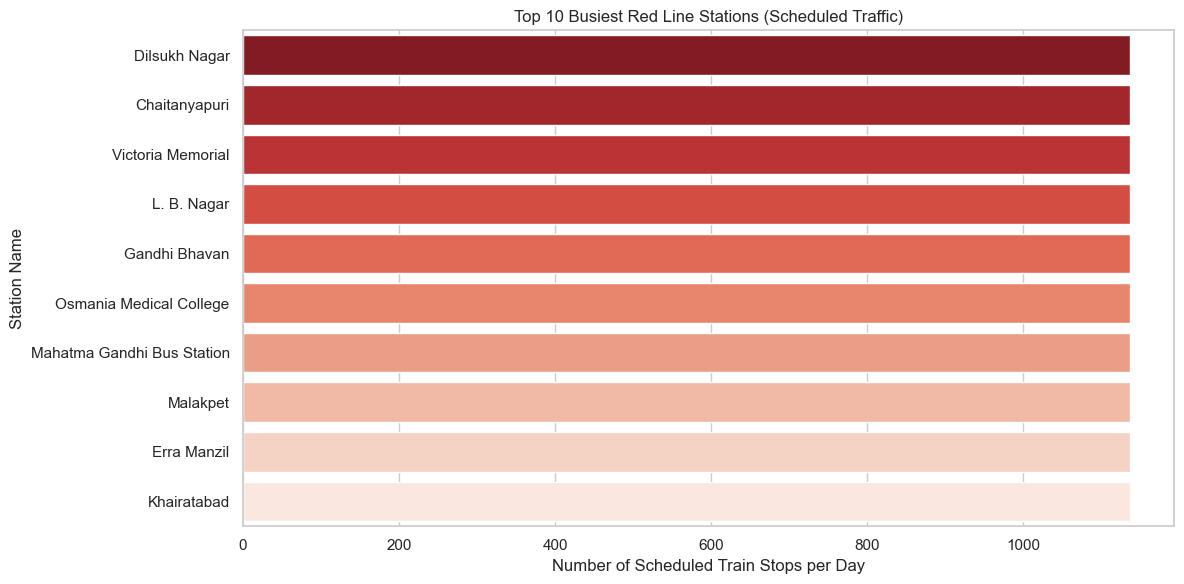

In [3]:
# Count the number of scheduled stops per station
busiest_stations = red_line_df['stop_name'].value_counts().reset_index()
busiest_stations.columns = ['Station Name', 'Scheduled Train Stops']

# Display the top 5
print("Top 5 Busiest Stations on the Red Line (By Scheduled Stops):")
print(busiest_stations.head())

# Plot the Top 10 Busiest Stations
plt.figure(figsize=(12, 6))
sns.barplot(data=busiest_stations.head(10), x='Scheduled Train Stops', y='Station Name', palette='Reds_r')
plt.title('Top 10 Busiest Red Line Stations (Scheduled Traffic)')
plt.xlabel('Number of Scheduled Train Stops per Day')
plt.ylabel('Station Name')
plt.tight_layout()
plt.show()

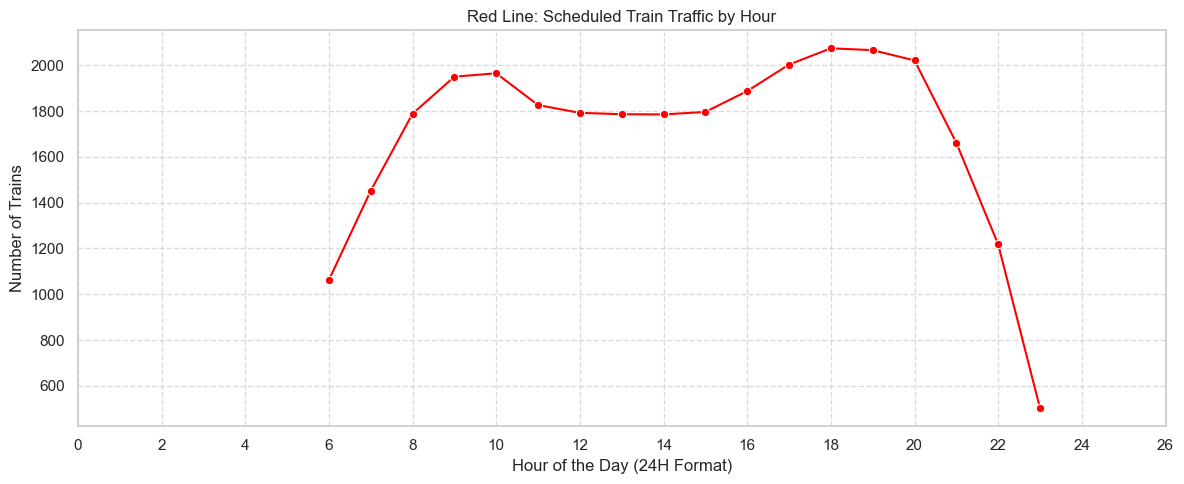

In [4]:
# GTFS times can sometimes go past 24:00:00 (e.g., 25:30:00 for 1:30 AM the next day)
# We safely extract the hour by splitting the string
red_line_df['hour'] = red_line_df['arrival_time'].str.split(':').str[0].astype(int)

# Count scheduled stops per hour
hourly_traffic = red_line_df['hour'].value_counts().sort_index().reset_index()
hourly_traffic.columns = ['Hour of Day', 'Number of Trains Scheduled']

# Plot the hourly traffic
plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_traffic, x='Hour of Day', y='Number of Trains Scheduled', marker='o', color='red')
plt.title('Red Line: Scheduled Train Traffic by Hour')
plt.xlabel('Hour of the Day (24H Format)')
plt.ylabel('Number of Trains')
plt.xticks(range(0, 28, 2)) # Adjust x-ticks to show every 2 hours
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [5]:
import folium

# 1. Extract unique stations and their exact coordinates for the Red Line
# We group by station name and take the first available latitude and longitude
station_coords = red_line_df.groupby('stop_name')[['stop_lat', 'stop_lon']].first().reset_index()

# 2. Find the geographic center of our map to set the initial view
center_lat = station_coords['stop_lat'].mean()
center_lon = station_coords['stop_lon'].mean()

# 3. Create the interactive base map (CartoDB positron gives a clean, light-colored map)
metro_map = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='CartoDB positron')

# 4. Loop through our stations and drop a marker for each one
for index, row in station_coords.iterrows():
    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=7,  # Size of the circle
        popup=folium.Popup(f"<b>{row['stop_name']} Station</b>", max_width=250),
        tooltip=f"Click for info: {row['stop_name']}", # Hover text
        color='#E32636', # Alizarin Crimson (Red)
        fill=True,
        fill_color='#E32636',
        fill_opacity=0.8
    ).add_to(metro_map)

# 5. Display the map directly in the notebook!
metro_map